## Plotting turbidity and constituent relationships across La Jara Samples fro Supporting Information
Note: Hex codes for viridis colors: 
- #440154 (Dark Purple / Violet)
- #3b528b (Deep Blue)
- #21918c (Teal)
- #5ec962 (Light Green)
- #fde725 (Yellow)

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from matplotlib.lines import Line2D

df = pd.read_csv("constituent_data.csv")
# get rid of accidental spaces from column names
df.columns = df.columns.str.strip()
numeric_cols = ["SS", "POC", "DOC", "PP", "SRP", "Turbidity", "fDOM"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["Sample ID"] = df["Sample ID"].astype(str).str.strip().str.lower()

# assign each observation to a sample group
def assign_group(sample_id):
    if sample_id.startswith("storm"):
        return "Summer storms"
    elif sample_id == "spring" or sample_id.startswith("spring"):
        return "Spring events"
    elif sample_id.startswith("experiment"):
        return "Experiments"

df["Group"] = df["Sample ID"].apply(assign_group)
print(df["Group"].value_counts(dropna=False))

Group
Experiments      105
Spring events     79
Summer storms     45
Name: count, dtype: int64


In [37]:
df

,Sample ID,SS,POC,DOC,PP,SRP,DateTime,Turbidity,fDOM,Lab ID,Group
0,storm-1,562.325833,51.659922,9.179,0.036946,0.062,7/23/2021 15:50,92.530400,25.1484,VC-BER-20,Summer storms
1,storm-1,528.034839,50.228119,12.625,0.050586,0.088,7/23/2021 16:09,197.947760,25.1140,VC-BER-21,Summer storms
2,storm-1,143.169047,14.502380,13.388,0.023867,0.088,7/23/2021 16:40,78.192980,37.8446,VC-BER-31,Summer storms
3,storm-1,82.761405,11.681075,12.997,0.015604,0.083,7/23/2021 16:55,74.057744,40.2548,VC-BER-22,Summer storms
4,storm-1,36.920032,6.410793,12.868,0.002961,0.053,7/23/2021 19:19,20.570200,52.5872,VC-BER-23,Summer storms
...,...,...,...,...,...,...,...,...,...,...,...
224,experiment-8,191.192091,NaN,2.936,NaN,NaN,11:15:32,NaN,NaN,90,Experiments
225,experiment-8,164.108426,17.196571,2.933,NaN,NaN,11:15:35,NaN,NaN,91,Experiments
226,experiment-8,119.197515,9.506040,2.634,NaN,NaN,11:15:38,NaN,NaN,92,Experiments
227,experiment-8,96.298777,6.367517,2.970,NaN,NaN,11:15:44,NaN,NaN,93,Experiments


Functions

In [38]:
# colors consistent across all four panels
group_colors = {
    "Summer storms": "#5ec962",  # lime green
    "Spring events": "#21918c",  # teal
    "Experiments":   "#fde725",    # yellow
}
group_order = ["Experiments", "Summer storms", "Spring events", ]

def calculate_r2(data, x_col, y_col):
    paired = data[[x_col, y_col]].dropna()
    if len(paired) < 2:
        return np.nan
    if paired[x_col].nunique() < 2 or paired[y_col].nunique() < 2:
        return np.nan
    regression = linregress(paired[x_col], paired[y_col])
    return regression.rvalue ** 2

def format_r2(value):
    if pd.isna(value):
        return "NA"
    return f"{value:.2f}"

def plot_relationship(ax, data, x_col, y_col, x_label, limx, r2_xy):
    panel_data = data[[x_col, y_col, "Group"]].dropna().copy()
    # scatter plots observations by group
    for group in group_order:
        subset = panel_data[panel_data["Group"] == group]
        ax.scatter(subset[x_col], subset[y_col], s=42, color=group_colors[group], edgecolor="black",
            linewidth=0.4, alpha=1, zorder=3, label=group)
    # full-dataset regression line only
    if (len(panel_data) >= 2
        and panel_data[x_col].nunique() >= 2
        and panel_data[y_col].nunique() >= 2
    ):
        fit = linregress(panel_data[x_col], panel_data[y_col])
        x_line = np.linspace(panel_data[x_col].min(), panel_data[x_col].max(), 200)
        y_line = fit.intercept + fit.slope * x_line
        ax.plot(x_line, y_line, linestyle="--", linewidth=1.8, zorder=2, color="#440154")

    # calculate the four R² values
    r2_all = calculate_r2(panel_data, x_col, y_col)

    r2_summer = calculate_r2(panel_data[panel_data["Group"] == "Summer storms"], x_col, y_col)
    r2_spring = calculate_r2(panel_data[panel_data["Group"] == "Spring events"], x_col, y_col)
    r2_experiments = calculate_r2(panel_data[panel_data["Group"] == "Experiments"], x_col, y_col)
    r2_entries = [
        ("All", r2_all, "#440154"),
        ("Summer", r2_summer, group_colors["Summer storms"]),
        ("Spring", r2_spring, group_colors["Spring events"]),
        ("Experiments", r2_experiments, group_colors["Experiments"]),
    ]
    highlight_colors = {
        "All": "#E9D5F5",          # light purple
        "Summer": "#D9F2D9",       # light green
        "Spring": "#D8EEF5",       # light teal
        "Experiments": "#FFF3B0"   # light yellow
    }

    entries = [
        ("All", r2_all),
        ("Summer", r2_summer),
        ("Spring", r2_spring),
        ("Experiments", r2_experiments),
    ]

    x_text, y_start = r2_xy
    dy = 0.08 # vertical distance between R² entries

    for label, value in entries:
        ax.text(
            x_text,
            y_start,
            rf"{label}: $R^2={format_r2(value)}$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="black",
            bbox=dict(
                facecolor=highlight_colors[label],
                edgecolor="none",
                boxstyle="round,pad=0",
                alpha=0.65
            ),
            zorder=10
        )
        y_start -= dy

    # panel formatting
    ax.set_xlabel(x_label)
    ax.set_xlim(-5, limx)
    ax.set_ylabel(f"{y_col} (mg/L)")

    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)

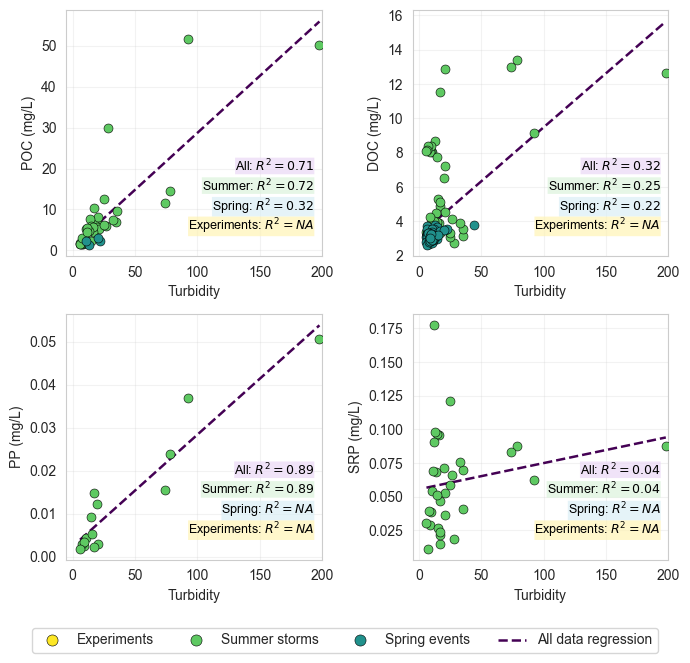

In [41]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7, 7))
relationships = [
    ("POC", (0.97, 0.40)),
    ("DOC", (0.97, 0.40)),
    ("PP",  (0.97, 0.40)),
    ("SRP", (0.97, 0.40))
]

for ax, (constituent, r2_xy) in zip(axes.flat, relationships):
    plot_relationship(
        ax=ax,
        data=df,
        x_col="Turbidity",
        y_col=constituent,
        x_label="Turbidity",
        limx=200, 
        r2_xy=r2_xy
    )

# shared legend
legend_handles = [Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=group_colors[group],
        markeredgecolor="black", markeredgewidth=0.4, markersize=8, label=group) for group in group_order]
# add the one regression-line symbol
legend_handles.append(
    Line2D([0], [0], linestyle="--", linewidth=1.8, label="All data regression", color="#440154"))
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, 0.01))
fig.tight_layout(rect=[0, 0.07, 1, 0.96])

plt.savefig("SI1_turbidity_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

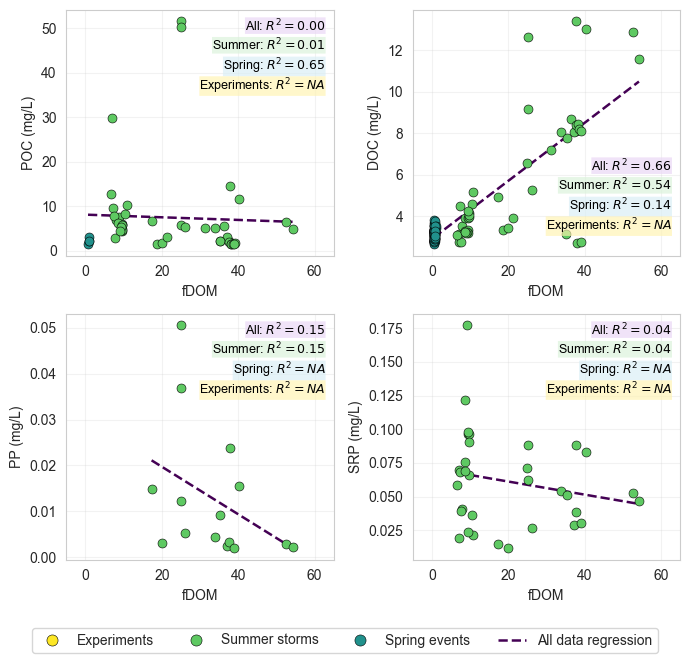

In [45]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7, 7))
relationships = [
    ("POC", (0.97, 0.97)),
    ("DOC", (0.97, 0.40)),
    ("PP",  (0.97, 0.97)),
    ("SRP", (0.97, 0.97))
]

for ax, (constituent, r2_xy) in zip(axes.flat, relationships):
    plot_relationship(
        ax=ax,
        data=df,
        x_col="fDOM",
        y_col=constituent,
        x_label="fDOM",
        limx=65,
        r2_xy=r2_xy
    )

# shared legend
legend_handles = [Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=group_colors[group],
        markeredgecolor="black", markeredgewidth=0.4, markersize=8, label=group) for group in group_order]
# add the one regression-line symbol
legend_handles.append(
    Line2D([0], [0], linestyle="--", linewidth=1.8, label="All data regression", color="#440154"))
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, 0.01))
fig.tight_layout(rect=[0, 0.07, 1, 0.96])

plt.savefig("SI1_fDOM_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

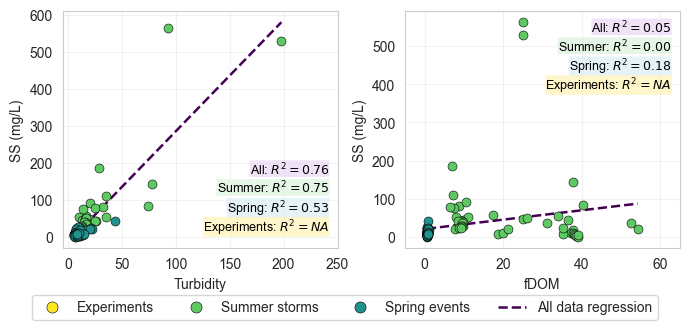

In [57]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3.5))
relationships = [
    ("Turbidity", (0.97, 0.37)),
    ("fDOM", (0.97, 0.97)),
]

for ax, (constituent, r2_xy) in zip(axes.flat, relationships):
    plot_relationship(
        ax=ax,
        data=df,
        x_col=constituent,
        y_col="SS",
        x_label=constituent,
        limx=250,
        r2_xy=r2_xy
    )

# fDOM  x-lim needs to be smaller
axes[1].set_xlim(-5, 65)
# shared legend
legend_handles = [Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=group_colors[group],
        markeredgecolor="black", markeredgewidth=0.4, markersize=8, label=group) for group in group_order]
# add the one regression-line symbol
legend_handles.append(
    Line2D([0], [0], linestyle="--", linewidth=1.8, label="All data regression", color="#440154"))
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=True, bbox_to_anchor=(0.5, 0.01))
fig.tight_layout(rect=[0, 0.07, 1, 0.96])

plt.savefig("SI1_SS_sonde_relationships.png", dpi=300, bbox_inches="tight")
plt.show()